In [56]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import torch
from einops import repeat
from scipy import stats
from sklearn.decomposition import PCA
import pandas as pd
import subprocess as sp
import re
import random
import yaml
from scipy.stats import gaussian_kde
import imageio
import os
from IPython.display import Image
from shapely.geometry import Point, Polygon
from tqdm import tqdm
from skimage import measure

from models.diffusion_model import EDM_CFG, edm_sampler, StackedRandomGenerator

In [218]:
database_denormalised = pd.read_csv("aerofoil_data_clean.csv")

In [219]:
def parse_array_from_string(s):
    # Remove brackets and split by whitespace
    s = s.strip().replace("[","").replace("]","")
    return np.array([float(v) for v in s.split()], dtype=float)

cols_to_normalize = ['x', 'y', 'Ma', 'Re', 'AOA', 'CL', 'CD']

max_values={}
min_values={}

for col in cols_to_normalize:
    if col == 'y':
        # Convert each row to a numeric array
        database_denormalised[col] = database_denormalised[col].apply(lambda x: parse_array_from_string(x) if isinstance(x, str) else np.array(x, dtype=float))

        # Compute global min and max across all y elements
        y_max = database_denormalised[col].apply(np.max).max()
        y_min = database_denormalised[col].apply(np.min).min()

        # Normalize
        database_denormalised[col] = database_denormalised[col].apply(lambda arr: (arr - y_min) / (y_max - y_min))
        
        max_values[col] = y_max
        min_values[col] = y_min
    
    elif col == 'x':
        # Convert each row to a numeric array
        database_denormalised[col] = database_denormalised[col].apply(lambda x: parse_array_from_string(x) if isinstance(x, str) else np.array(x, dtype=float))

        # Compute global min and max across all y elements
        x_max = database_denormalised[col].apply(np.max).max()
        x_min = database_denormalised[col].apply(np.min).min()

        # Normalize
        database_denormalised[col] = database_denormalised[col].apply(lambda arr: (arr - x_min) / (x_max - x_min))
        
        max_values[col] = x_max
        min_values[col] = x_min
    
    else:
        col_min = database_denormalised[col].min()
        col_max = database_denormalised[col].max()
        database_denormalised[col] = (database_denormalised[col] - col_min) / (col_max - col_min)
        max_values[col] = col_max
        min_values[col] = col_min
# database_denormalised.to_csv('aerofoil_data_normalised_256.csv')

print('max:', max_values)
print('min:', min_values)

# row = {}

# for col in cols_to_normalize:
#     row[f"{col}_max"] = max_values[col]
#     row[f"{col}_min"] = min_values[col]

# df_min_max = pd.DataFrame([row])
# df_min_max.to_csv("min_max_256.csv", index=False)

max: {'x': 1.01, 'y': 0.2655612, 'Ma': 0.6, 'Re': 350000, 'AOA': 10.0, 'CL': 1.9996, 'CD': 0.05}
min: {'x': -0.009702712, 'y': -0.1618754, 'Ma': 0.0, 'Re': 200000, 'AOA': 0.0, 'CL': -0.0, 'CD': 0.00285}


In [206]:
def parse_array_from_string(s):

    s = s.strip().replace("[", "").replace("]", "")
    return np.array([float(v) for v in s.split()])



database = pd.read_csv("aerofoil_data_256.csv")


# ==============================================================
# 1. FILTER DATA
# ==============================================================
# Conditions
CL_min, CL_max = 0.0, 2.0
CD_min, CD_max = 0.0, 0.05

database_clean = database[
    (database["CL"] >= CL_min) & (database["CL"] <= CL_max) &
    (database["CD"] >= CD_min) & (database["CD"] <= CD_max)
].copy()

database_clean.to_csv("aerofoil_data_clean.csv", index=False)
print("Saved aerofoil_data_clean.csv")


# ==============================================================
# 2. NORMALIZE CLEAN DATA
# ==============================================================
cols_to_normalize = ['y', 'Ma', 'Re', 'AOA', 'CL', 'CD']

max_values = {}
min_values = {}

# We work on a copy to avoid accidental corruption
df_norm = database_clean.copy()

for col in cols_to_normalize:

    if col == 'y':
        # Parse array-like column
        df_norm[col] = df_norm[col].apply(parse_array_from_string)

        # Compute global min/max across concatenated arrays
        y_max = df_norm[col].apply(np.max).max()
        y_min = df_norm[col].apply(np.min).min()

        # Normalize each array
        df_norm[col] = df_norm[col].apply(lambda arr: (arr - y_min) / (y_max - y_min))

        max_values[col] = y_max
        min_values[col] = y_min

    else:
        col_min = df_norm[col].min()
        col_max = df_norm[col].max()

        # Min-max normalization
        df_norm[col] = (df_norm[col] - col_min) / (col_max - col_min)

        max_values[col] = col_max
        min_values[col] = col_min


# Save normalized dataset
df_norm.to_csv("aerofoil_data_clean_normalised.csv", index=False)
print("Saved aerofoil_data_clean_normalised.csv")


row = {}
for col in cols_to_normalize:
    row[f"{col}_max"] = max_values[col]
    row[f"{col}_min"] = min_values[col]

df_minmax = pd.DataFrame([row])
df_minmax.to_csv("min_max_clean.csv", index=False)
print("Saved min_max_clean.csv")

print(df_minmax)


Saved aerofoil_data_clean.csv
Saved aerofoil_data_clean_normalised.csv
Saved min_max_clean.csv

=== Normalization ranges ===
      y_max     y_min  Ma_max  Ma_min  Re_max  Re_min  AOA_max  AOA_min  \
0  0.265561 -0.161875     0.6     0.0  350000  200000     10.0      0.0   

   CL_max  CL_min  CD_max   CD_min  
0  1.9996    -0.0    0.05  0.00285  


In [41]:
def xfoil_calculation(x,y,AOA,Re,Ma,CL,CD):
    
    geom_file_name = f'generated_geom/profile_{AOA:.1f}_{Ma:.1f}_{int(Re)}_{CL:.1f}_{CD:.1f}'
    result_file_name = f'generated_data/profile_{AOA:.1f}_{Ma:.1f}_{int(Re)}_{CL:.1f}_{CD:.1f}'
    xfoilpath = '/home/yg1922/Desktop/Xfoil_2/bin/xfoil'

    with open(f'{geom_file_name}', "w") as f:
        f.write(f'generated_profile_{AOA:.1f}_{Ma:.1f}_{int(Re)}_{CL:.2f}_{CD:.2f}' + "\n")  # First line
    
        for xi, yi in zip(x, y):
            f.write(f"{xi} {yi}\n")

    # Delete the previous run results
    for f in [result_file_name]:
        try:
            os.remove(f)
        except FileNotFoundError:
            pass

    def Xfoil(Ma, Re):
        xfoil_commands = f"""
            PLOP
            G F

            LOAD {geom_file_name}

            OPER
            ITER 500
            MACH {Ma}
            VISC {Re}
            PACC
            {result_file_name}

            ALFA {AOA}

            QUIT
            """

        try:
            ps = sp.Popen([xfoilpath],
                        stdin=sp.PIPE,
                        stdout=sp.PIPE,
                        stderr=sp.PIPE)

            stdout, stderr = ps.communicate(input=xfoil_commands.encode(), timeout = 30)

            ps.stdin.close()
            ps.stdout.close()
            ps.stderr.close()

        except sp.TimeoutExpired:
            print('error in ', geom_file_name)
            ps.kill()
            print('Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.')
            

        except Exception as e:
            print(f"Error running {geom_file_name}: {e}")
            print('Something unexpected happened')
            ps.kill()

    Xfoil(Ma=Ma, Re=Re)


    f = open(result_file_name, 'r', errors='ignore')
    flines = f.readlines()


    if len(flines) != 12: 
        for i in range(12, len(flines)):
            words = str.split(flines[i]) 
            CL_actual    = float(words[1])
            CD_actual    = float(words[2])
            LD_r  = float(words[1]) / float(words[2])
    else:
        print('There is no output from xfoil. Possibly because the profile generated is not feasible.')
        CL_actual = 999
        CD_actual = 999
    return CL_actual, CD_actual

In [80]:
def validation_plot(model,  sample_size, data_structure, device, pca = None, num_steps = None, manual_seed = None):
    plt.rcdefaults()
    model.eval()
    df = pd.read_csv("aerofoil_data_clean_normalised.csv")
    df2 = pd.read_csv("aerofoil_data_clean.csv")
    val_indices = np.load("val_indices_clean.npy")
    train_indices = np.load("train_indices_clean.npy")

    if manual_seed != None:
        random.seed(manual_seed)
        print('exe', manual_seed)
    numbers = random.sample(range(0, len(val_indices)), sample_size)

    min_max = pd.read_csv('min_max_clean.csv')
    y_max = min_max['y_max'].loc[0]
    y_min = min_max['y_min'].loc[0]
    
    for idx in numbers:
        
        i = val_indices[idx]
        x_str = df.loc[i, 'x']
        x_str = re.sub(r'[\[\]]', '', x_str)   # remove brackets
        x_coords_original = [float(v) for v in x_str.split()]
        
        y_str = df.loc[i, 'y']
        y_str = re.sub(r'[\[\]]', '', y_str)   # remove brackets
        y_coords_original = np.array([float(v) for v in y_str.split()])
        y_coords_original = y_coords_original * (y_max - y_min) + y_min


        name = df.loc[i,'name']
        Ma_normalised = df.loc[i, 'Ma']
        Re_normalised = df.loc[i, 'Re']
        AOA_normalised = df.loc[i, 'AOA']
        CL_normalised = df.loc[i, 'CL']
        CD_normalised = df.loc[i, 'CD']

        
        # denormalise the condition data
        Ma = Ma_normalised*(min_max['Ma_max'].loc[0]-min_max['Ma_min'].loc[0])+min_max['Ma_min'].loc[0]
        Re = Re_normalised*(min_max['Re_max'].loc[0]-min_max['Re_min'].loc[0])+min_max['Re_min'].loc[0]
        AOA = AOA_normalised*(min_max['AOA_max'].loc[0]-min_max['AOA_min'].loc[0])+min_max['AOA_min'].loc[0]
        CL = CL_normalised*(min_max['CL_max'].loc[0]-min_max['CL_min'].loc[0])+min_max['CL_min'].loc[0]
        CD = CD_normalised*(min_max['CD_max'].loc[0]-min_max['CD_min'].loc[0])+min_max['CD_min'].loc[0]

        # convert the condition data into a tensor
        cond = (torch.tensor([AOA_normalised, Ma_normalised, Re_normalised, CL_normalised, CD_normalised]).to(device))

        # use the model to generate coordinates
        


        if data_structure!='sdf':
            rnd = StackedRandomGenerator(device, range(sample_size))
            latents = rnd.randn([sample_size, model.in_dim], device=device)
            with torch.no_grad():
                samples, _ = edm_sampler(model, latents=latents, class_labels=cond, randn_like=rnd.randn_like, num_steps=num_steps, deterministic=True) 
            samples = samples.float()
            sample = samples[0].cpu().numpy()
            print(f"{num_steps} sampling steps")
        
        if data_structure == 'pca':
            sample = pca.inverse_transform(sample)

        if data_structure == 'sdf':
            x_resolution = 256
            y_resolution = 256
            x_lower_lim = -0.01
            x_upper_lim = 1.01
            y_lower_lim = -0.17
            y_upper_lim = 0.27
            rnd = StackedRandomGenerator(device, range(sample_size))
            latents = torch.randn(sample_size, 1, 256, 256, device=device)
            with torch.no_grad():
                samples, _ = edm_sampler(model, latents=latents, class_labels=cond, randn_like=rnd.randn_like, num_steps=num_steps, deterministic=True) 
            samples = samples.float()
            sample = samples[0].cpu().numpy()
            print(f"{num_steps} sampling steps")
            xs = np.linspace(x_lower_lim, x_upper_lim, x_resolution)
            ys = np.linspace(y_lower_lim, y_upper_lim, y_resolution)

            sample_img = sample.reshape(y_resolution, x_resolution)

            fig, ax = plt.subplots()
            contour = ax.contourf(xs, ys, sample_img, levels=100, cmap='Spectral')
            ax.contourf(xs, ys, sample_img, levels=100, cmap='Spectral')
            # ax.contour(xs, ys, sample_img, levels=[0], colors='b')
            fig.colorbar(contour, ax=ax, label="Signed Distance")
        else:
            # denormalise the generated coordinates
            x_coords = sample[0::2]
            y_coords_normalised = sample[1::2]
            y_coords = y_coords_normalised*(y_max - y_min)+y_min

            # xfoil to calculate the data for the genrated design
            CL_actual, CD_actual = xfoil_calculation(x_coords, y_coords, AOA, Re, Ma, CL, CD)


            same_intended_cond_val_idx = []
            same_intended_cond_train_idx = []
            same_actual_cond_val_idx = []
            same_actual_cond_train_idx = []
            for idx in range(len(df2)):
                if int(df2['AOA'].iloc[idx]) == int(AOA):
                    if int(df2['Re'].iloc[idx]) == int(Re):
                        if round(df2['Ma'].iloc[idx], 1) == round(Ma, 1):
                            if abs((df2['CD'].iloc[idx] - CD)/df2['CD'].iloc[idx]) <=0.01:
                                if abs((df2['CL'].iloc[idx] - CL)/df2['CL'].iloc[idx]) <=0.01:
                                    if idx in val_indices:
                                        same_intended_cond_val_idx.append(idx)
                                        print('Same intended conditions in validation set', df2['name'].iloc[idx], 'in the validation set.')
                                    elif idx in train_indices:
                                        same_intended_cond_train_idx.append(idx)
                                        print('Same intended conditions in training set', df2['name'].iloc[idx], 'in the training set.')
                            elif abs((df2['CD'].iloc[idx] - CD_actual)/df2['CD'].iloc[idx]) <=0.01:
                                if abs((df2['CL'].iloc[idx] - CL_actual)/df2['CL'].iloc[idx]) <=0.01:
                                    if idx in val_indices:
                                        same_actual_cond_val_idx.append(idx)
                                        print('Same actual conditions in validation set', df2['name'].iloc[idx], 'in the validation set.')
                                    elif idx in train_indices:
                                        same_actual_cond_train_idx.append(idx)
                                        print('Same actual conditions in training set', df2['name'].iloc[idx], 'in the training set.')
            # Plotting function
            fig, ax1 = plt.subplots()
            ax1.grid(True, ls=':')
            ax1.plot(x_coords,y_coords, color = 'b', label = 'generated')
            count1 = 0
            count2 = 0
            for i in same_intended_cond_val_idx:
                name = df.loc[i, 'name']
                x_str = df.loc[i, 'x']
                x_str = re.sub(r'[\[\]]', '', x_str)   # remove brackets
                x_coords_original = [float(v) for v in x_str.split()]
                
                y_str = df.loc[i, 'y']
                y_str = re.sub(r'[\[\]]', '', y_str)   # remove brackets
                y_coords_original = np.array([float(v) for v in y_str.split()])
                y_coords_original = y_coords_original * (y_max - y_min) + y_min
                if count1 == 0:
                    ax1.plot(x_coords_original,y_coords_original, c = 'r', ls = ':', label = f'validation set')
                else:
                    ax1.plot(x_coords_original,y_coords_original, c = 'r',ls = ':')
                count1 = count1 + 1

            for i in same_intended_cond_train_idx:
                name = df.loc[i, 'name']
                x_str = df.loc[i, 'x']
                x_str = re.sub(r'[\[\]]', '', x_str)   # remove brackets
                x_coords_original = [float(v) for v in x_str.split()]
                
                y_str = df.loc[i, 'y']
                y_str = re.sub(r'[\[\]]', '', y_str)   # remove brackets
                y_coords_original = np.array([float(v) for v in y_str.split()])
                y_coords_original = y_coords_original * (y_max - y_min) + y_min
                if count2 == 0:
                    ax1.plot(x_coords_original,y_coords_original, c = 'g', ls = ':', label = f'training set')
                else:
                    ax1.plot(x_coords_original,y_coords_original, c = 'g', ls = ':')
                count2 = count2 + 1

            ax1.set_ylim(-0.4,0.4)
            ax1.set_xlabel('x')
            ax1.set_ylabel('y')
            ax1.set_title(
                    f"{name} \n"
                    f"Ma: {Ma:.1f} "
                    f"Re: {int(Re)} "
                    f"AOA: {int(AOA)} deg \n"
                    f"Intended CD: {CD:.2f} "
                    f"Intended CL: {CL:.2f} \n"
                    f"Actual CD: {CD_actual:.2f} "
                    f"Actual CL: {CL_actual:.2f} "
                    )
            ax1.legend()
            plt.show()
            
            fig, ax2 = plt.subplots()
            ax2.grid(True, ls=':')
            ax2.plot(x_coords,y_coords, color = 'b', label = 'generated')
            count1 = 0
            count2 = 0
            for i in same_actual_cond_val_idx:
                name = df.loc[i, 'name']
                x_str = df.loc[i, 'x']
                x_str = re.sub(r'[\[\]]', '', x_str)   # remove brackets
                x_coords_original = [float(v) for v in x_str.split()]
                
                y_str = df.loc[i, 'y']
                y_str = re.sub(r'[\[\]]', '', y_str)   # remove brackets
                y_coords_original = np.array([float(v) for v in y_str.split()])
                y_coords_original = y_coords_original * (y_max - y_min) + y_min
                if count1 == 0:
                    ax2.plot(x_coords_original,y_coords_original, c = 'r', ls = ':', label = f'validation set')
                else:
                    ax2.plot(x_coords_original,y_coords_original, c = 'r',ls = ':')
                count1 = count1 + 1

            for i in same_actual_cond_train_idx:
                name = df.loc[i, 'name']
                x_str = df.loc[i, 'x']
                x_str = re.sub(r'[\[\]]', '', x_str)   # remove brackets
                x_coords_original = [float(v) for v in x_str.split()]
                
                y_str = df.loc[i, 'y']
                y_str = re.sub(r'[\[\]]', '', y_str)   # remove brackets
                y_coords_original = np.array([float(v) for v in y_str.split()])
                y_coords_original = y_coords_original * (y_max - y_min) + y_min
                if count2 == 0:
                    ax2.plot(x_coords_original,y_coords_original, c = 'g', ls = ':', label = f'training set')
                else:
                    ax2.plot(x_coords_original,y_coords_original, c = 'g', ls = ':')
                count2 = count2 + 1

            ax2.set_ylim(-0.4,0.4)
            ax2.set_xlabel('x')
            ax2.set_ylabel('y')
            ax2.legend()
            plt.show()

In [43]:
def test_plot(AOA, Ma, Re, CL, CD, data_structure, model, device, pca=None, num_steps = None):
    
    plt.rcdefaults()
    model.eval()
    min_max = pd.read_csv('min_max_256.csv')
    y_max = min_max['y_max'].loc[0]
    y_min = min_max['y_min'].loc[0]

    normalised_Ma = (Ma-min_max['Ma_min'].loc[0])/(min_max['Ma_max'].loc[0]-min_max['Ma_min'].loc[0])
    normalised_Re = (Re-min_max['Re_min'].loc[0])/(min_max['Re_max'].loc[0]-min_max['Re_min'].loc[0])
    normalised_AOA = (AOA-min_max['AOA_min'].loc[0])/(min_max['AOA_max'].loc[0]-min_max['AOA_min'].loc[0])
    normalised_CL = (CL-min_max['CL_min'].loc[0])/(min_max['CL_max'].loc[0]-min_max['CL_min'].loc[0])
    normalised_CD = (CD-min_max['CD_min'].loc[0])/(min_max['CD_max'].loc[0]-min_max['CD_min'].loc[0])


    cond = (torch.tensor([normalised_AOA, normalised_Ma, normalised_Re, normalised_CL, normalised_CD]).to(device))
    rnd = StackedRandomGenerator(device, range(1))
    latents = rnd.randn([1, model.in_dim], device=device)
    
    with torch.no_grad():
        samples, _ = edm_sampler(model, latents=latents, class_labels=cond, randn_like=rnd.randn_like, deterministic=True, num_steps=num_steps) 
    print(f"{num_steps} sampling steps")
    samples = samples.float()
    sample = samples[0].cpu().numpy()
    
    if data_structure == 'pca':
        sample = pca.inverse_transform(sample)

    x_coords = sample[0::2]
    y_coords_normalised = sample[1::2]
    y_coords = y_coords_normalised*(y_max - y_min)+y_min

    CL_actual, CD_actual = xfoil_calculation(x_coords, y_coords, AOA, Re, Ma, CL, CD)

    fig, ax = plt.subplots()
    ax.grid(True, ls=':')
    ax.plot(x_coords,y_coords, color = 'b', label = 'generated')
    ax.set_ylim(-0.4,0.4)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(
            f"Ma: {Ma:.1f} "
            f"Re: {int(Re)} "
            f"AOA: {int(AOA)} deg \n"
            f"Intended CD: {CD:.2f} "
            f"Intended CL: {CL:.2f} \n"
            f"Actual CD: {CD_actual:.2f} "
            f"Actual CL: {CL_actual:.2f} ")
    
    ax.legend()
    plt.show()

In [44]:
def validation_accuracy(model_config_path, band = None, mode = None, CL_axis_min = None, CL_axis_max = None, CD_axis_min = None, CD_axis_max = None):
    
    with open(model_config_path, "r") as f:
        model_config = yaml.safe_load(f)

    data_structure = model_config['data_structure']
    num_epochs = model_config['num_epochs']
    model_channel = model_config['model_channel']
    model_layer = model_config['model_layer']
    model_channel_multiplication = model_config['model_channel_multiplication']
    nn_structure=model_config['neural_network_sturcture']
    model_code = f"{data_structure}_{nn_structure}_{model_channel}_{model_layer}_{len(model_channel_multiplication)}_with_{num_epochs}_epochs"

    
    results = pd.read_csv(f"mdl_validation/{model_code}.csv")

    CL = []
    CD = []
    CL_actual = []
    CD_actual = []
    unfeasible = 0
    
    for idx in range(len(results)):
        if results['CL_actual'].loc[idx] == 999:
            unfeasible = unfeasible + 1
        else:
            CL.append(results['CL'].loc[idx])
            CD.append(results['CD'].loc[idx])
            CL_actual.append(results['CL_actual'].loc[idx])
            CD_actual.append(results['CD_actual'].loc[idx])

    CL = np.array(CL)
    CD = np.array(CD)
    CL_actual = np.array(CL_actual)
    CD_actual = np.array(CD_actual)

    CL_error = (CL - CL_actual)/CL
    CD_error = (CD - CD_actual)/CD

    CL_sum_of_square = 0
    CD_sum_of_square = 0
    
    CL_in_bound = 0
    CD_in_bound = 0

    band_1 = band # change here to change the error band
    upper_band_grad = 1 + band_1
    lower_band_grad = 1 - band_1

    for idx, i in enumerate(CL_error):
        if CL[idx] >= CL_axis_min and CL[idx] <= CL_axis_max: 
            if abs(i) <= upper_band_grad-1:
                CL_in_bound += 1
            elif abs(i) < 999:
                CL_sum_of_square = CL_sum_of_square + i**2
            else:
                print('Outlier in CL')
    CL_rmse = (CL_sum_of_square/len(CL_error))**0.5
        

    for idx, i in enumerate(CD_error):
        if CD[idx] >= CD_axis_min and CD[idx] <= CD_axis_max: 
            if abs(i) <= upper_band_grad-1:
                CD_in_bound += 1
            elif abs(i) < 999:
                CD_sum_of_square = CD_sum_of_square + i**2
            else:
                print('Outlier in CD')
    CD_rmse = (CD_sum_of_square/len(CD_error))**0.5
    

    print(f'The validation takes {len(results)} samples, among which {unfeasible} ({100*(unfeasible/len(results)):.2f}%) designs are unfeasible')
    print(f'The accuracy information of the {len(CL)} feasible designs are shown below:')
    print('CL RMSE is:', CL_rmse)
    print('CD RMSE is:', CD_rmse)
    print(f'{int(100*(CL_in_bound)/(len(CL)))}% samples have CL within {int(band_1*100)}% relative error.')
    print(f'{int(100*(CD_in_bound)/(len(CL)))}% samples have CD within {int(band_1*100)}% relative error.')

    fig, axes = plt.subplots(1,2, figsize=(12,5))

    ax1 = axes[0]
    ax2 = axes[1]

    # CL_padding = 0.1
    # CD_padding = 0.01
    # CL_min = min(CL) - CL_padding
    # CL_max = max(CL) + CL_padding
    # CD_min = min(CD) - CD_padding
    # CD_max = max(CD) + CD_padding
    
    # CL_actual_min = min(CL_actual) - CL_padding
    # CL_actual_max = max(CL_actual) + CL_padding
    # CD_actual_min = min(CD_actual) - CD_padding
    # CD_actual_max = max(CD_actual) + CD_padding

    # CL_axis_lower_limit = min(CL_actual_min, CL_min)
    # CL_axis_upper_limit = max(CL_actual_max, CL_max)
    # CD_axis_lower_limit = min(CD_actual_min, CD_min)
    # CD_axis_upper_limit = max(CD_actual_max, CD_max)
    CL_axis_lower_limit = CL_axis_min
    CL_axis_upper_limit = CL_axis_max
    CD_axis_lower_limit = CD_axis_min
    CD_axis_upper_limit = CD_axis_max

    # ================================= KDE
    x = np.array(CL)
    y = np.array(CL_actual)
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    xx, yy = np.mgrid[CL_axis_min:CL_axis_max:200j, CL_axis_min:CL_axis_max:200j]
    grid_coords = np.vstack([xx.ravel(), yy.ravel()])
    density = kde(grid_coords).reshape(xx.shape)
    # =================================

    if mode == 'scatter':
        ax1.scatter(CL, CL_actual, s=5, label = 'Generated Point')
    elif mode == 'heatmap':
        ax1.imshow(density.T, origin='lower', extent=[CL_axis_min, CL_axis_max, CL_axis_min, CL_axis_max], cmap='Reds', aspect='auto')
    
    m_cl, b_cl = np.polyfit(CL, CL_actual, 1)
    # ax1.plot(np.linspace(CL_min, CL_max, 10), m_cl*np.linspace(CL_axis_lower_limit, CL_axis_upper_limit, 10) + b_cl, c='g', ls = ':') # line of best fit
    ax1.plot(np.linspace(CL_axis_lower_limit, CL_axis_upper_limit, 10), np.linspace(CL_axis_lower_limit, CL_axis_upper_limit, 10), c='r', ls='--', label = '100% Accuracy') # line with grad = 1
    ax1.plot(np.linspace(CL_axis_lower_limit, CL_axis_upper_limit, 10), upper_band_grad*np.linspace(CL_axis_lower_limit, CL_axis_upper_limit, 10), c='r', ls=':', label = f'{int(band_1*100)}% band') # upperbound of 10% error
    ax1.plot(np.linspace(CL_axis_lower_limit, CL_axis_upper_limit, 10), lower_band_grad*np.linspace(CL_axis_lower_limit, CL_axis_upper_limit, 10), c='r', ls=':') # lowerbound of 10% error
    ax1.set_xlabel('Intended CL')
    ax1.set_ylabel('Generated CL')
    ax1.set_xlim(CL_axis_lower_limit, CL_axis_upper_limit)
    ax1.set_ylim(CL_axis_lower_limit, CL_axis_upper_limit)
    ax1.legend()

    # ================================= KDE
    x = np.array(CD)
    y = np.array(CD_actual)
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    xx, yy = np.mgrid[CD_axis_min:CD_axis_max:200j, CD_axis_min:CD_axis_max:200j]
    grid_coords = np.vstack([xx.ravel(), yy.ravel()])
    density = kde(grid_coords).reshape(xx.shape)
    # =================================

    if mode == 'scatter':
        ax2.scatter(CD, CD_actual, s=5)
    elif mode == 'heatmap':
        ax2.imshow(density.T, origin='lower', extent=[CD_axis_min, CD_axis_max, CD_axis_min, CD_axis_max], cmap='Reds', aspect='auto')
    
    m_cd, b_cd = np.polyfit(CD, CD_actual, 1)
    # ax2.plot(np.linspace(CD_min, CD_max, 10), m_cd*np.linspace(CD_axis_lower_limit, CD_axis_upper_limit, 10) + b_cd, c='g', ls = ':') # line of best fit
    ax2.plot(np.linspace(CD_axis_lower_limit, CD_axis_upper_limit, 10), np.linspace(CD_axis_lower_limit, CD_axis_upper_limit, 10), c='r', ls='--') # line with grad = 1
    ax2.plot(np.linspace(CD_axis_lower_limit, CD_axis_upper_limit, 10), upper_band_grad*np.linspace(CD_axis_lower_limit, CD_axis_upper_limit, 10), c='r', ls=':') # upperbound of 10% error
    ax2.plot(np.linspace(CD_axis_lower_limit, CD_axis_upper_limit, 10), lower_band_grad*np.linspace(CD_axis_lower_limit, CD_axis_upper_limit, 10), c='r', ls=':') # lowerbound of 10% error
    ax2.set_xlabel('Intended CD')
    ax2.set_ylabel('Generated CD')
    ax2.set_xlim(CD_axis_lower_limit, CD_axis_upper_limit)
    ax2.set_ylim(CD_axis_lower_limit, CD_axis_upper_limit)
    plt.show()

    print("CL best-fit-line gradient is:", m_cl)
    print("CD best-fit-line gradient is:", m_cd)


In [45]:
def denoise_process_plot(model, data_structure, device, sample_size,num_steps, pca, fig_size, manual_seed = None):

    model.eval()
    df = pd.read_csv("aerofoil_data_normalised_256.csv")
    val_indices = np.load("val_indices_256.npy")
    # numbers = random.sample(range(0, len(val_indices)), sample_size)
    if manual_seed != None:
        random.seed(manual_seed)
    numbers = random.sample(range(0, len(val_indices)), sample_size)

    min_max = pd.read_csv('min_max_256.csv')
    y_max = min_max['y_max'].loc[0]
    y_min = min_max['y_min'].loc[0]
    
    for idx in numbers:
        
        i = val_indices[idx]
        x_str = df.loc[i, 'x']
        x_str = re.sub(r'[\[\]]', '', x_str)
        x_coords_original = [float(v) for v in x_str.split()]
        
        y_str = df.loc[i, 'y']
        y_str = re.sub(r'[\[\]]', '', y_str)
        y_coords_original = np.array([float(v) for v in y_str.split()])
        y_coords_original = y_coords_original * (y_max - y_min) + y_min

        name = df.loc[i,'name']
        Ma_normalised = df.loc[i, 'Ma']
        Re_normalised = df.loc[i, 'Re']
        AOA_normalised = df.loc[i, 'AOA']
        CL_normalised = df.loc[i, 'CL']
        CD_normalised = df.loc[i, 'CD']

        
        # denormalise the condition data
        Ma = Ma_normalised*(min_max['Ma_max'].loc[0]-min_max['Ma_min'].loc[0])+min_max['Ma_min'].loc[0]
        Re = Re_normalised*(min_max['Re_max'].loc[0]-min_max['Re_min'].loc[0])+min_max['Re_min'].loc[0]
        AOA = AOA_normalised*(min_max['AOA_max'].loc[0]-min_max['AOA_min'].loc[0])+min_max['AOA_min'].loc[0]
        CL = CL_normalised*(min_max['CL_max'].loc[0]-min_max['CL_min'].loc[0])+min_max['CL_min'].loc[0]
        CD = CD_normalised*(min_max['CD_max'].loc[0]-min_max['CD_min'].loc[0])+min_max['CD_min'].loc[0]

        # convert the condition data into a tensor
        cond = (torch.tensor([AOA_normalised, Ma_normalised, Re_normalised, CL_normalised, CD_normalised]).to(device))

        # use the model to generate coordinates
        rnd = StackedRandomGenerator(device, range(sample_size))
        latents = rnd.randn([sample_size, model.in_dim], device=device)
        with torch.no_grad():
            samples, trajectory = edm_sampler(model, latents=latents, class_labels=cond, randn_like=rnd.randn_like, num_steps=num_steps, deterministic=True) 
        samples = samples.float()
        sample = samples[0].cpu().numpy()
        print(f"{num_steps} sampling steps")
        
        if data_structure == 'pca':
            sample = pca.inverse_transform(sample)

        # denormalise the generated coordinates
        x_coords = sample[0::2]
        y_coords_normalised = sample[1::2]
        y_coords = y_coords_normalised*(y_max - y_min)+y_min

        # xfoil to calculate the data for the genrated design
        CL_actual, CD_actual = xfoil_calculation(x_coords, y_coords, AOA, Re, Ma, CL, CD)

        frames = []  # store frame paths
        output_dir = "frames"
        os.makedirs(output_dir, exist_ok=True)

        # Plotting function
        for i in range(num_steps):
            samples = trajectory[i]
            samples = samples.float()
            sample = samples[0].cpu().numpy()

            if data_structure == 'pca':
                sample = pca.inverse_transform(sample)

            # denormalise the generated coordinates
            x_coords = sample[0::2]
            y_coords_normalised = sample[1::2]
            y_coords = y_coords_normalised*(y_max - y_min)+y_min
            
            fig, ax = plt.subplots(figsize=fig_size, dpi = 300)
            ax.grid(True, ls=':')
            ax.plot(x_coords,y_coords, color = 'b', label = 'generated')
            ax.plot(x_coords_original,y_coords_original, color = 'r', label = 'original')
            ax.set_xlim(-0.1, 1.1)
            ax.set_ylim(-0.4,0.4)
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            if i == num_steps-1:
                ax.set_title(' \n'
                            f'Denoising Sampling Step {i+1} \n'
                            f"Ma: {Ma:.1f} "
                            f"Re: {int(Re)} "
                            f"AOA: {int(AOA)} deg \n"
                            f"Intended CD: {CD:.2f} "
                            f"Intended CL: {CL:.2f} \n"
                            f"Actual CD: {CD_actual:.2f} "
                            f"Actual CL: {CL_actual:.2f} ")
            else:
                ax.set_title(f'Denoising Sampling Step {i+1}')
            ax.legend()


            frame_path = f"{output_dir}/frame_{i}.png"
            plt.savefig(frame_path)
            plt.close(fig)

            frames.append(frame_path)

        gif_path = f"denoising_gif/denoising_process_{data_structure}_{num_steps}.gif"
        with imageio.get_writer(gif_path, mode="I", duration=2.0) as writer:
            for frame in frames:
                writer.append_data(imageio.imread(frame))

        for frame in frames:
            os.remove(frame)

        print("GIF saved as:", gif_path)
    Image(filename=gif_path)

In [51]:
def model_deployment(mode, model_config_path, sample_number=1, AOA=None, Ma=None, Re=None, CL=None, CD=None, num_steps = None, fig_size = None, manual_seed = None):
    with open(model_config_path, "r") as f:
        model_config = yaml.safe_load(f)

    data_structure = model_config['data_structure']
    num_epochs = model_config['num_epochs']
    model_channel = model_config['model_channel']
    model_layer = model_config['model_layer']
    model_channel_multiplication = model_config['model_channel_multiplication']
    device=model_config['device']
    nn_structure=model_config['neural_network_sturcture']
    model_code = f"{data_structure}_{nn_structure}_{model_channel}_{model_layer}_{len(model_channel_multiplication)}_with_{num_epochs}_epochs"
    save_path = f"mdl_weight/{model_code}.pth"
    print('Model Code', model_code)
    num_components=model_config['component_number']
    
    if data_structure == 'pca':
        
        df = pd.read_csv("aerofoil_data_normalised_256.csv")
        combined_coordinates = []
        for _, row in df.iterrows():
            x_coords = np.fromstring(row["x"].strip("[]"), sep=" ")
            y_coords = np.fromstring(row["y"].strip("[]"), sep=" ")
            paired = np.column_stack((x_coords, y_coords)).flatten()
            combined_coordinates.append(paired)
        coordinates = np.array(combined_coordinates)
        pca = PCA(n_components=num_components)
        coordinates = pca.fit_transform(coordinates)

        model = EDM_CFG(num_components, num_components, cond_size=5, model_channel=model_channel,
                channel_multiply=model_channel_multiplication, dim_mult_emb=4, num_blocks=model_layer,
                dropout=0, emb_type="sinusoidal", dim_mult_time=1, nn_structure=nn_structure,
                dim_mult_cond=1, cond_drop_prob=0, adaptive_scale=True, skip_scale=1.0, affine=False, data_structure=data_structure, 
                    number_of_pc = num_components)
        model.load_state_dict(torch.load(save_path))


    elif data_structure == 'raw_coordinates':
        
        model = EDM_CFG(num_components, num_components, cond_size=5, model_channel=model_channel,
                channel_multiply=model_channel_multiplication, dim_mult_emb=4, num_blocks=model_layer,
                dropout=0, emb_type="sinusoidal", dim_mult_time=1, nn_structure=nn_structure,
                dim_mult_cond=1, cond_drop_prob=0, adaptive_scale=True, skip_scale=1.0, affine=False, data_structure=data_structure, 
                    number_of_pc = num_components)
        pca = None
        model.load_state_dict(torch.load(save_path))

    elif data_structure == 'sdf':
        
        model = EDM_CFG(num_components, num_components, cond_size=5, model_channel=model_channel,
                channel_multiply=model_channel_multiplication, dim_mult_emb=4, num_blocks=model_layer,
                dropout=0, emb_type="sinusoidal", dim_mult_time=1, nn_structure=nn_structure,
                dim_mult_cond=1, cond_drop_prob=0, adaptive_scale=True, skip_scale=1.0, affine=False, data_structure=data_structure, 
                    number_of_pc = num_components)
        pca = None
        model.load_state_dict(torch.load(save_path))



    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    if mode == 'validation':
        validation_plot(model, sample_number, data_structure, device, pca, num_steps, manual_seed)
    elif mode == 'test':
        test_plot(AOA, Ma, Re, CL, CD, data_structure, model, device, pca, num_steps)
    elif mode == 'denoise_process_plot':
        denoise_process_plot(model, data_structure, device, sample_number, num_steps, pca, fig_size, manual_seed)


Model Code sdf_ResNet_UNet_2D_64_3_4_with_100_epochs
Total parameters: 100,625,665
30 sampling steps


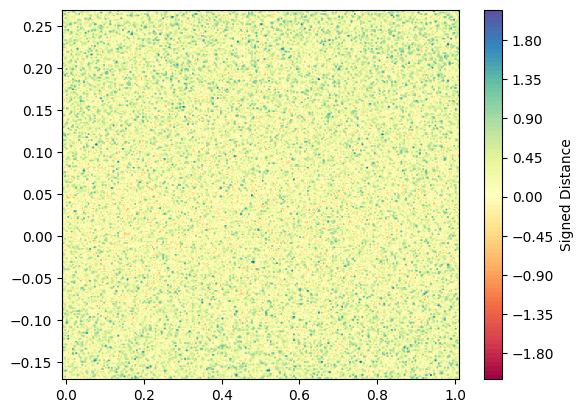

In [81]:
model_deployment(mode = 'validation', model_config_path='mdl_hyperparams/sdf_conv2d_unet.yaml', sample_number=1, num_steps=30)

Model Code pca_ResNet_UNet_64_5_4_with_100_epochs
Total parameters: 61,785,601
30 sampling steps


/tmp/ipykernel_143813/877453697.py:106: RuntimeWarning: divide by zero encountered in scalar divide
  if abs((df2['CL'].iloc[idx] - CL)/df2['CL'].iloc[idx]) <=0.01:
/tmp/ipykernel_143813/877453697.py:114: RuntimeWarning: divide by zero encountered in scalar divide
  if abs((df2['CL'].iloc[idx] - CL_actual)/df2['CL'].iloc[idx]) <=0.01:


Same intended conditions in validation set s4110.dat in the validation set.


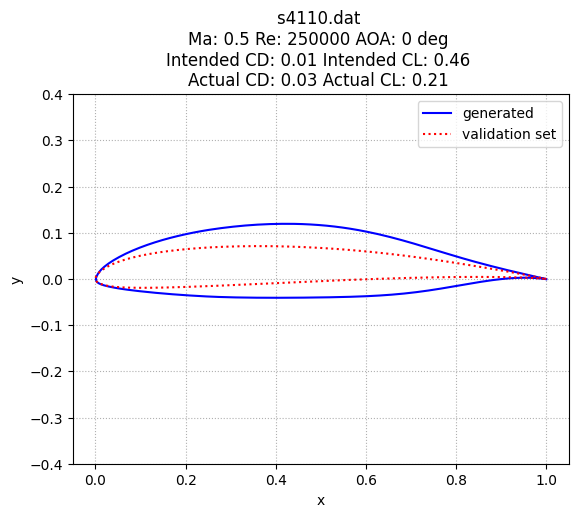

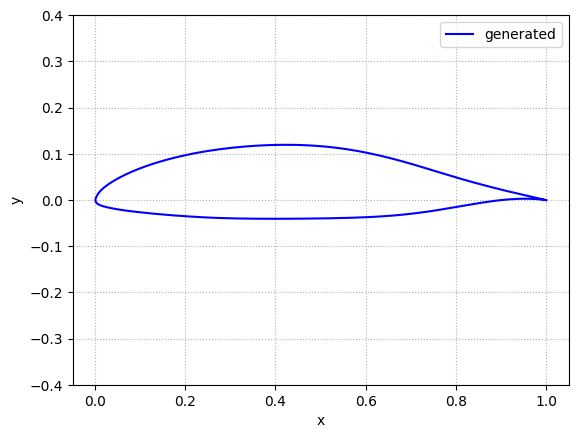

In [68]:
model_deployment(mode = 'validation', model_config_path='mdl_hyperparams/pca_unet.yaml', sample_number=1, num_steps=30)

Model Code raw_coordinates_ResNet_UNet_64_5_4_with_100_epochs
Total parameters: 61,785,986
exe 345
30 sampling steps
There is no output from xfoil. Possibly because the profile generated is not feasible.
Same intended conditions in validation set e432.dat in the validation set.


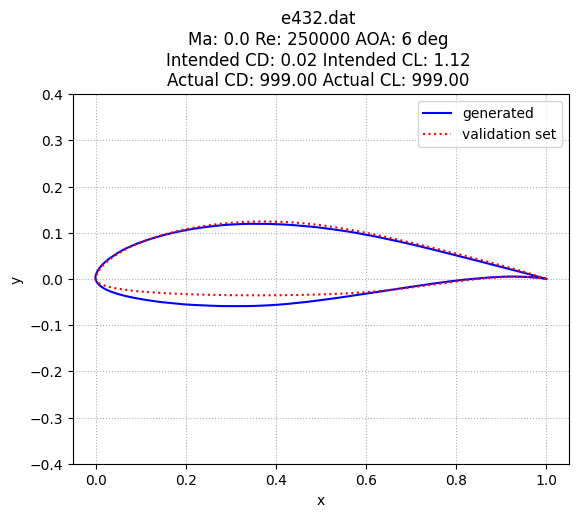

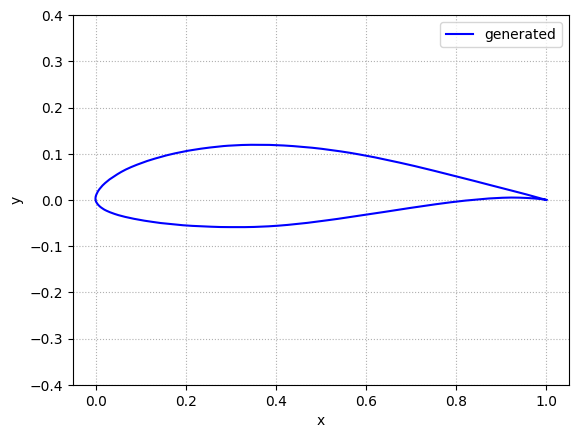

In [71]:
model_deployment(mode = 'validation', model_config_path='mdl_hyperparams/raw_coords_conv1d_deep_unet.yaml', sample_number=1,  num_steps=30, manual_seed=345)

Model Code pca_MLP_128_5_4_with_100_epochs
Total parameters: 34,081,940
30 sampling steps


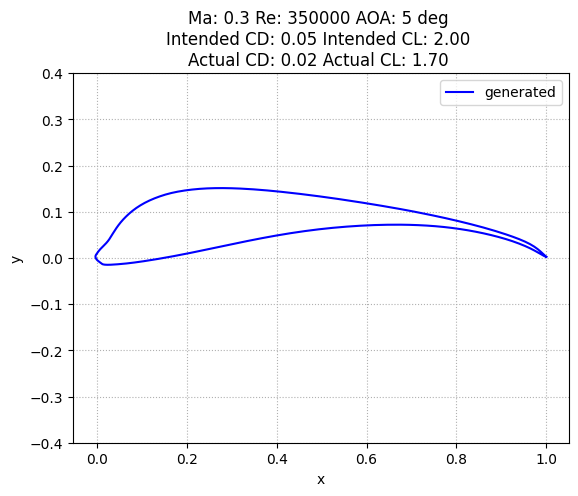

In [115]:
model_deployment(mode = 'test', model_config_path='mdl_hyperparams/pca_mlp.yaml', sample_number=None, AOA=5, Ma=0.3, Re=350000, CL=2, CD=0.05, num_steps=30)

Model Code raw_coordinates_ResNet_UNet_64_5_4_with_100_epochs
Total parameters: 61,785,986
18 sampling steps


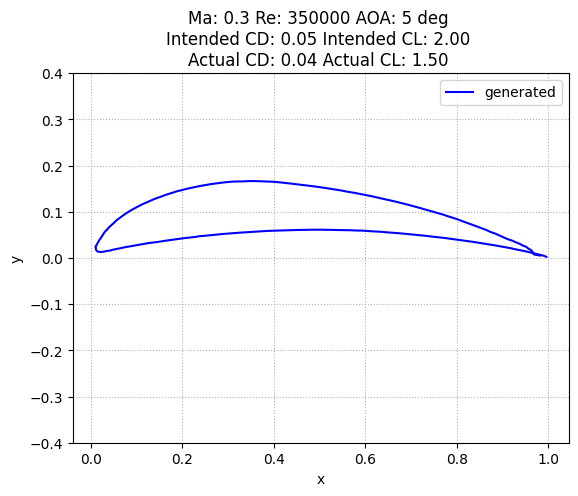

In [223]:
model_deployment(mode = 'test', model_config_path='mdl_hyperparams/raw_coords_conv1d_deep_unet.yaml', sample_number=None, AOA=5, Ma=0.3, Re=350000, CL=2, CD=0.05, num_steps=18)

/tmp/ipykernel_746198/1112432024.py:37: RuntimeWarning: divide by zero encountered in divide
  CL_error = (CL - CL_actual)/CL


Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
The validation takes 745 samples, among which 182 (24.43%) designs are unfeasible
The accuracy information of the 563 feasible designs are shown below:
CL RMSE is: 0.06652940887162359
CD RMSE is: 0.10189068864202114
87% samples have CL within 10% relative error.
76% samples have CD within 10% relative error.


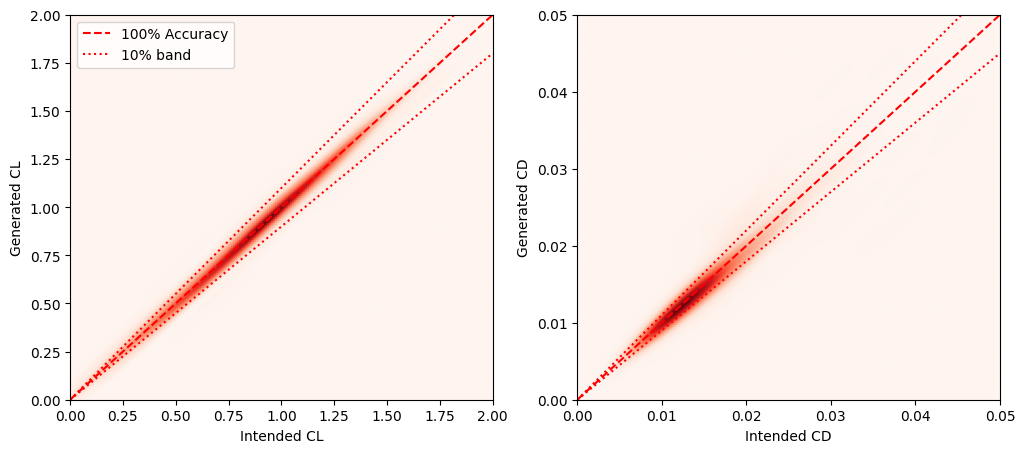

CL best-fit-line gradient is: 0.9895840293014199
CD best-fit-line gradient is: 0.9520554463872919


In [10]:
validation_accuracy(model_config_path='mdl_hyperparams/raw_coords_conv1d_deep_unet.yaml', band = 0.1, mode = 'heatmap', CL_axis_min=0, CL_axis_max=2, CD_axis_min=0, CD_axis_max=0.05)

/tmp/ipykernel_746198/1112432024.py:37: RuntimeWarning: divide by zero encountered in divide
  CL_error = (CL - CL_actual)/CL


Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
Outlier in CL
The validation takes 745 samples, among which 182 (24.43%) designs are unfeasible
The accuracy information of the 563 feasible designs are shown below:
CL RMSE is: 0.06652940887162359
CD RMSE is: 0.10189068864202114
87% samples have CL within 10% relative error.
76% samples have CD within 10% relative error.


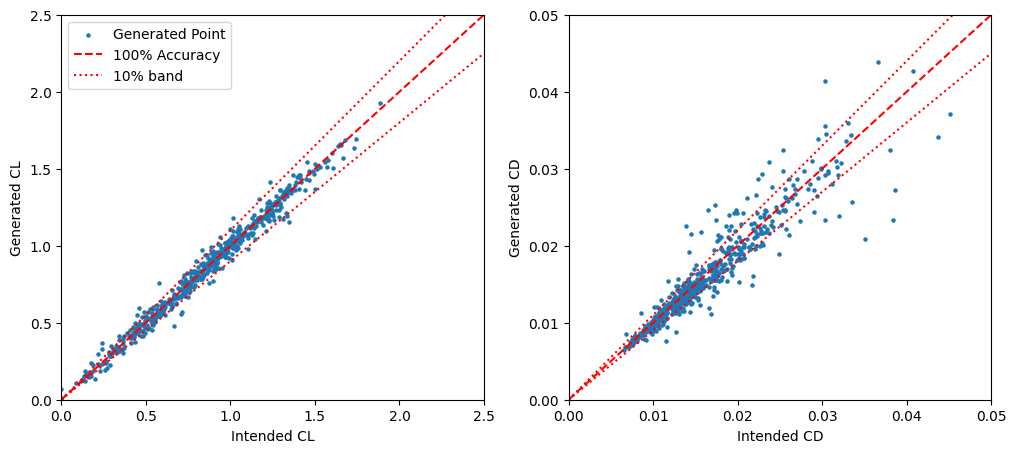

CL best-fit-line gradient is: 0.9895840293014199
CD best-fit-line gradient is: 0.9520554463872919


In [9]:
validation_accuracy(model_config_path='mdl_hyperparams/raw_coords_conv1d_deep_unet.yaml', band = 0.1, mode = 'scatter', CL_axis_min=0, CL_axis_max=2.5, CD_axis_min=0, CD_axis_max=0.05)

The validation takes 771 samples, among which 203 (26.33%) designs are unfeasible
The accuracy information of the 568 feasible designs are shown below:
CL RMSE is: 0.12153290550821845
CD RMSE is: 0.10595321391576253
83% samples have CL within 10% relative error.
73% samples have CD within 10% relative error.


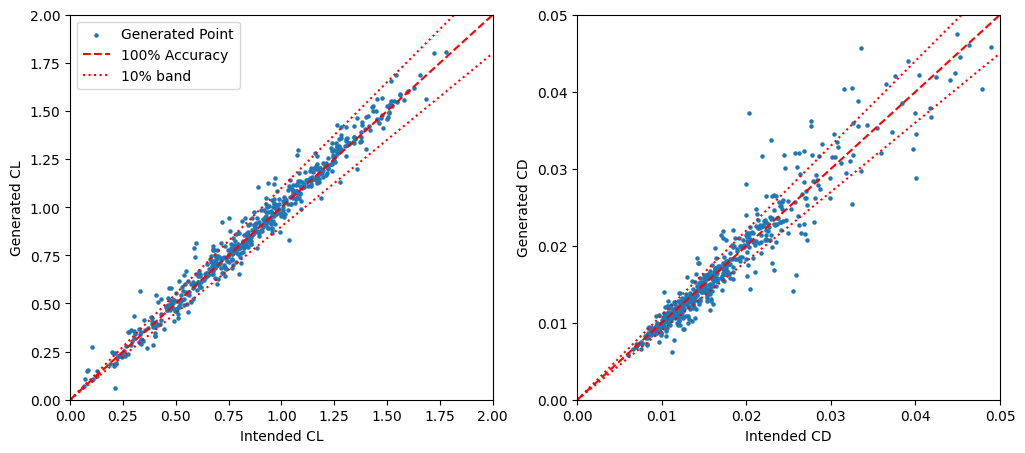

CL best-fit-line gradient is: 1.002804164272837
CD best-fit-line gradient is: 0.9965511609199269


In [204]:
validation_accuracy(model_config_path='mdl_hyperparams/pca_unet.yaml', band = 0.1, mode = 'scatter', CL_axis_min=0, CL_axis_max=2, CD_axis_min=0, CD_axis_max=0.05)

The validation takes 771 samples, among which 203 (26.33%) designs are unfeasible
The accuracy information of the 568 feasible designs are shown below:
CL RMSE is: 0.12153290550821845
CD RMSE is: 0.10595321391576253
83% samples have CL within 10% relative error.
73% samples have CD within 10% relative error.


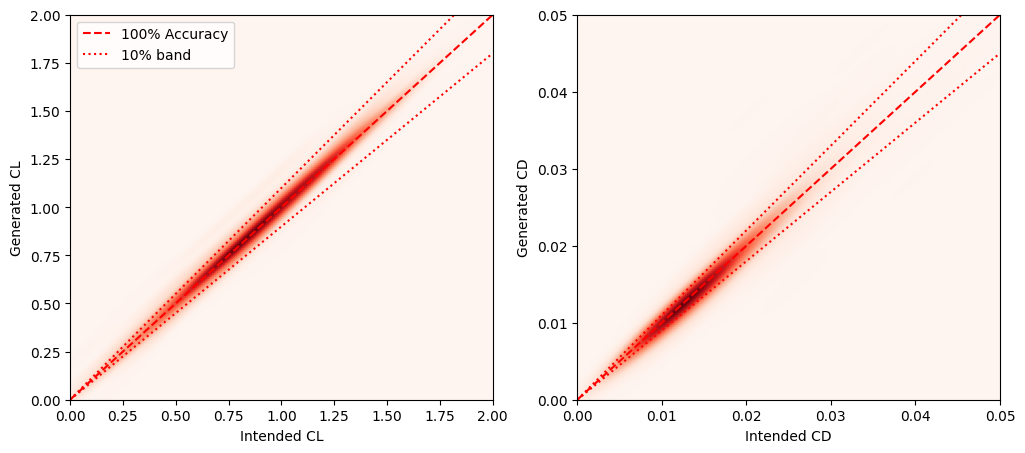

CL best-fit-line gradient is: 1.002804164272837
CD best-fit-line gradient is: 0.9965511609199269


In [205]:
validation_accuracy(model_config_path='mdl_hyperparams/pca_unet.yaml', band = 0.1, mode = 'heatmap', CL_axis_min=0, CL_axis_max=2, CD_axis_min=0, CD_axis_max=0.05)

In [70]:
model_deployment(mode = 'denoise_process_plot', model_config_path='mdl_hyperparams/raw_coords_conv1d_deep_unet.yaml', sample_number=1,  num_steps=30, fig_size=(6,6))

Model Code raw_coordinates_ResNet_UNet_64_5_4_with_100_epochs
Total parameters: 61,785,986
30 sampling steps


/tmp/ipykernel_113371/194742077.py:112: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(frame))


GIF saved as: denoising_gif/denoising_process_raw_coordinates_30.gif


In [ ]:
model_deployment(mode = 'denoise_process_plot', model_config_path='mdl_hyperparams/pca_mlp.yaml', sample_number=1,  num_steps=30, fig_size=(6,6))

Model Code pca_MLP_128_5_4_with_100_epochs


Total parameters: 34,081,940
30 sampling steps


/tmp/ipykernel_3722255/266861965.py:112: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(frame))


GIF saved as: denoising_gif/denoising_process_pca_30.gif


In [ ]:
df = pd.read_csv('aerofoil_data_clean_normalised.csv')

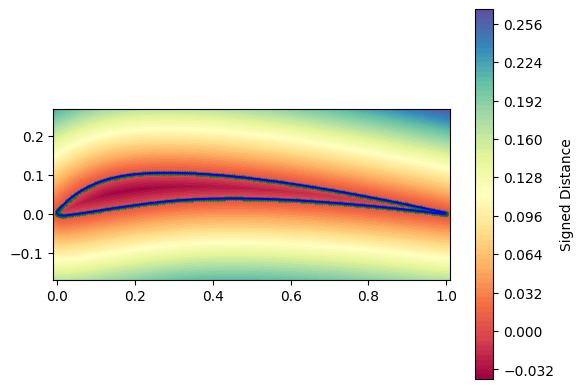

In [228]:
import pandas as pd
import numpy as np
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt

idx = 5

x_resolution = 256
y_resolution = 256
x_lower_lim = -0.01
x_upper_lim = 1.01
y_lower_lim = -0.17
y_upper_lim = 0.27

x_str = df.loc[idx, 'x']
x_str = re.sub(r'[\[\]]', '', x_str)
x_coords_original = [float(v) for v in x_str.split()]

y_str = df.loc[idx, 'y']
y_str = re.sub(r'[\[\]]', '', y_str)
y_coords_original = np.array([float(v) for v in y_str.split()])

y_coords_original = y_coords_original * (y_max - y_min) + y_min
coords = []


for i in range(len(y_coords_original)):
    coords.append((x_coords_original[i], y_coords_original[i]))
poly = Polygon(coords)



xs = np.linspace(x_lower_lim, x_upper_lim, x_resolution)
ys = np.linspace(y_lower_lim, y_upper_lim, y_resolution)
X, Y = np.meshgrid(xs, ys)


sdf = np.zeros_like(X)

for i in range(y_resolution):
    for j in range(x_resolution):
        p = Point(X[i, j], Y[i, j])
        dist = p.distance(poly.exterior)

        if poly.contains(p):
            sdf[i, j] = -dist
        else:
            sdf[i, j] = dist


fig, ax = plt.subplots()
cont = ax.contourf(X, Y, sdf, levels=100, cmap='Spectral')
ax.contourf(X, Y, sdf, levels=100, cmap='Spectral')
ax.contour(X, Y, sdf, levels=[0], colors='b')  # zero contour = airfoil
ax.scatter(x_coords_original,y_coords_original, c='g', s = 6, marker = 'x')
fig.colorbar(cont, ax=ax, label="Signed Distance")
ax.set_ylim(y_lower_lim, y_upper_lim)
ax.set_aspect('equal', adjustable='box')
plt.show()

In [ ]:
# Neuralfoil validation - not possible to handle compressible fluid with M > 0
import pandas as pd
import numpy as np
import neuralfoil as nf
import matplotlib.pyplot as plt
import re

df = pd.read_csv('aerofoil_data_normalised.csv')


idx = 234

x_str = df.loc[idx, 'x']
x_str = re.sub(r'[\[\]]', '', x_str)
x_coords_original = [float(v) for v in x_str.split()]

y_str = df.loc[idx, 'y']
y_str = re.sub(r'[\[\]]', '', y_str)
y_coords_original = np.array([float(v) for v in y_str.split()])

y_coords_original = y_coords_original * (y_max - y_min) + y_min

Ma_normalised = df.loc[idx, 'Ma']
Re_normalised = df.loc[idx, 'Re']
AOA_normalised = df.loc[idx, 'AOA']
CL_normalised = df.loc[idx,'CL']
CD_normalised = df.loc[idx,'CD']


Ma = Ma_normalised*(max_values['Ma']-min_values['Ma'])+min_values['Ma']
Re = Re_normalised*(max_values['Re']-min_values['Re'])+min_values['Re']
AOA = AOA_normalised*(max_values['AOA']-min_values['AOA'])+min_values['AOA']
CL = CL_normalised*(max_values['CL']-min_values['CL'])+min_values['CL']
CD = CD_normalised*(max_values['CD']-min_values['CD'])+min_values['CD']


print(Ma, Re, AOA, CL, CD)



coords = np.column_stack([x_coords_original, y_coords_original])


aero = nf.get_aero_from_coordinates(coordinates=coords, alpha = AOA, Re = Re)
print(aero)

0.5 350000.0 5.0 1.455 0.018589999999999978
{'analysis_confidence': array([0.92464807]), 'CL': array([1.24293306]), 'CD': array([0.01345828]), 'CM': array([-0.12637221]), 'Top_Xtr': array([0.30670978]), 'Bot_Xtr': array([1.]), 'upper_bl_theta_0': array([0.00014669]), 'upper_bl_theta_1': array([0.00018475]), 'upper_bl_theta_2': array([0.00021178]), 'upper_bl_theta_3': array([0.0002567]), 'upper_bl_theta_4': array([0.00032127]), 'upper_bl_theta_5': array([0.00038724]), 'upper_bl_theta_6': array([0.00043324]), 'upper_bl_theta_7': array([0.00046077]), 'upper_bl_theta_8': array([0.00049532]), 'upper_bl_theta_9': array([0.00057387]), 'upper_bl_theta_10': array([0.00072811]), 'upper_bl_theta_11': array([0.00094868]), 'upper_bl_theta_12': array([0.00114926]), 'upper_bl_theta_13': array([0.00130467]), 'upper_bl_theta_14': array([0.0014165]), 'upper_bl_theta_15': array([0.00152175]), 'upper_bl_theta_16': array([0.00164989]), 'upper_bl_theta_17': array([0.00181239]), 'upper_bl_theta_18': array([0

In [ ]:
x_resolution = 256
y_resolution = 256
x_lower_lim = -0.01
x_upper_lim = 1.01
y_lower_lim = -0.17
y_upper_lim = 0.27


df = pd.read_csv("aerofoil_data_clean.csv")


def parse_array(s):
    s = re.sub(r"[\[\]]", "", str(s))
    return np.array([float(v) for v in s.split()], dtype=float)

unique_names = df['name'].unique()


print(f"Detected {len(unique_names)} unique airfoil shapes")


xs = np.linspace(x_lower_lim, x_upper_lim, x_resolution)
ys = np.linspace(y_lower_lim, y_upper_lim, y_resolution)
X, Y = np.meshgrid(xs, ys)


for name in tqdm(unique_names):

    sub = df[df['name'] == name].iloc[0]

    x_vals = parse_array(sub['x'])
    y_vals = parse_array(sub['y'])

    coords = [(x_vals[i], y_vals[i]) for i in range(len(x_vals))]
    poly = Polygon(coords)

    sdf = np.zeros_like(X)

    for i in range(y_resolution):
        for j in range(x_resolution):
            p = Point(X[i, j], Y[i, j])
            dist = p.distance(poly.exterior)
            sdf[i, j] = -dist if poly.contains(p) else dist

    np.save(f"sdf_matrix/{name}.npy", sdf)

print("All aerofoil SDF matrices saved")

Detected 1474 unique airfoil shapes


100%|██████████| 1474/1474 [14:33<00:00,  1.69it/s]

All aerofoil SDF matrices saved


In [3]:
import pandas as pd
df = pd.read_csv("aerofoil_data_256.csv")
unique_names = df['name'].unique()
print(f"Detected {len(unique_names)} unique airfoil shapes")

Detected 1476 unique airfoil shapes


In [16]:
df = pd.read_csv("aerofoil_data_clean.csv")

[ 0.998  0.998  0.998  0.998  0.994  0.994  0.99   0.986  0.982  0.978
  0.978  0.974  0.97   0.966  0.962  0.962  0.958  0.954  0.95   0.95
  0.946  0.942  0.938  0.934  0.934  0.93   0.926  0.922  0.918  0.918
  0.914  0.91   0.906  0.902  0.902  0.898  0.894  0.89   0.886  0.886
  0.882  0.878  0.874  0.87   0.87   0.866  0.862  0.858  0.854  0.854
  0.85   0.846  0.842  0.838  0.838  0.834  0.83   0.826  0.822  0.822
  0.818  0.814  0.81   0.806  0.802  0.802  0.798  0.794  0.79   0.786
  0.782  0.782  0.778  0.774  0.77   0.766  0.766  0.762  0.758  0.754
  0.75   0.746  0.742  0.742  0.738  0.734  0.73   0.726  0.722  0.722
  0.718  0.714  0.71   0.706  0.702  0.702  0.698  0.694  0.69   0.686
  0.682  0.678  0.678  0.674  0.67   0.666  0.662  0.658  0.654  0.65
  0.65   0.646  0.642  0.638  0.634  0.63   0.626  0.622  0.622  0.618
  0.614  0.61   0.606  0.602  0.598  0.594  0.59   0.59   0.586  0.582
  0.578  0.574  0.57   0.566  0.562  0.558  0.554  0.55   0.55   0.546
  0.542 

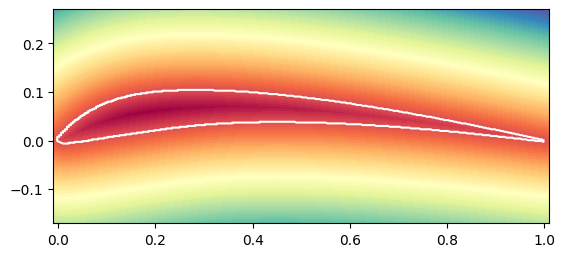

In [39]:

def reorder_airfoil_points(x, y):
    # Ensure closed
    if not (np.isclose(x[0], x[-1]) and np.isclose(y[0], y[-1])):
        x = np.r_[x, x[0]]
        y = np.r_[y, y[0]]
        print('not closed')

    i_te = np.argmax(x)
    x = np.roll(x, -i_te)
    y = np.roll(y, -i_te)

    if y[1] < 0:  
        x = np.concatenate([x[:1], x[:0:-1]])
        y = np.concatenate([y[:1], y[:0:-1]])

    return x, y


# --- Load SDF ---
aaa = np.load("sdf_matrix/2032c.dat.npy")

# Sampling grid
x_resolution = 256
y_resolution = 256
xs = np.linspace(x_lower_lim, x_upper_lim, x_resolution)
ys = np.linspace(y_lower_lim, y_upper_lim, y_resolution)


contours = measure.find_contours(aaa, level=0.0)

# Take largest connected contour = airfoil body
airfoil = max(contours, key=len)

# Convert pixel indices to real coordinates
x_coords = xs[airfoil[:, 1].astype(int)]
y_coords = ys[airfoil[:, 0].astype(int)]


x_sorted, y_sorted = reorder_airfoil_points(x_coords, y_coords)

# Plot
fig, ax = plt.subplots()
ax.contourf(xs, ys, aaa, levels=100, cmap='Spectral')
ax.plot(x_sorted, y_sorted, 'w')
print(x_sorted)
print('hihihihi')
print(y_sorted)
ax.set_aspect('equal', 'box')
plt.show()
